cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction
License(s): CC0-1.0
100% 4.63k/4.63k [00:00<00:00, 6.15MB/s]

Archive:  housing-price-prediction.zip
  inflating: Housing.csv             
First 5 rows of dataset:
       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnishe

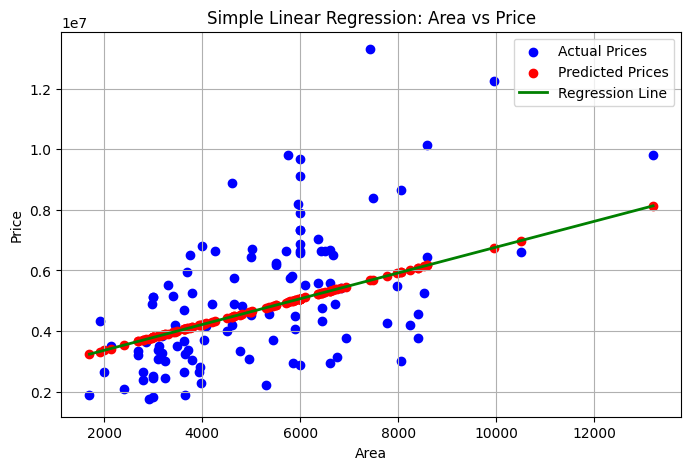


----- Multiple Linear Regression Results -----
MSE : 2784597954908.526
RMSE: 1668711.4654452775
R²  : 0.4490930347809541


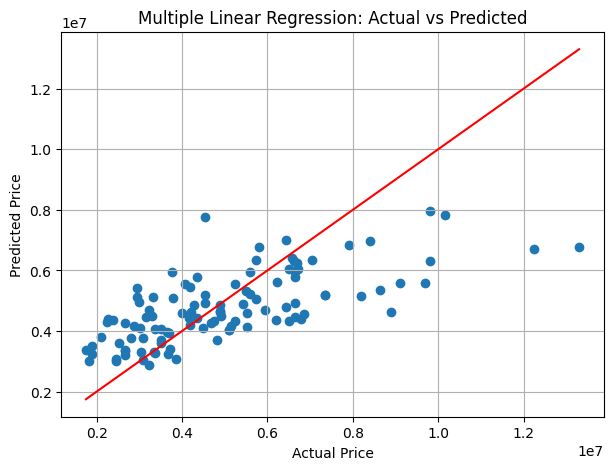


========== MODEL COMPARISON ==========
Simple LR   -> MSE: 3675286604768.1855 RMSE: 1917103.7021424235 R²: 0.27287851871974633
Multiple LR -> MSE: 2784597954908.526 RMSE: 1668711.4654452775 R²: 0.4490930347809541


In [4]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# ============================================
# STEP 2: Download Housing Dataset
# ============================================

!kaggle datasets download -d harishkumardatalab/housing-price-prediction


# ============================================
# STEP 3: Unzip Dataset
# ============================================

!unzip housing-price-prediction.zip


# ============================================
# STEP 4: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


# ============================================
# STEP 5: Load Dataset
# ============================================

df = pd.read_csv("Housing.csv")

print("First 5 rows of dataset:\n", df.head())

print("\nMissing values before preprocessing:\n")
print(df.isnull().sum())


# ============================================
# STEP 6: Data Preprocessing
# ============================================

df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMissing values after preprocessing:\n")
print(df.isnull().sum())


# ============================================
# STEP 7: Simple Linear Regression
# (Area -> Price)
# ============================================

X_simple = df[['area']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

scaler_simple = StandardScaler()

X_train_scaled = scaler_simple.fit_transform(X_train)
X_test_scaled = scaler_simple.transform(X_test)

simple_model = LinearRegression()

simple_model.fit(X_train_scaled, y_train)

y_pred_simple = simple_model.predict(X_test_scaled)


# ============================================
# STEP 8: Evaluation of Simple LR
# ============================================

mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("\n----- Simple Linear Regression Results -----")
print("MSE :", mse_simple)
print("RMSE:", rmse_simple)
print("R²  :", r2_simple)


# ============================================
# STEP 9: Visualization of Simple LR
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, color='blue', label='Actual Prices')

plt.scatter(X_test, y_pred_simple,
            color='red',
            label='Predicted Prices')

sorted_idx = np.argsort(X_test.values.flatten())

plt.plot(X_test.values.flatten()[sorted_idx],
         y_pred_simple[sorted_idx],
         color='green',
         linewidth=2,
         label='Regression Line')

plt.title("Simple Linear Regression: Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.legend()
plt.grid()

plt.show()


# ============================================
# STEP 10: Multiple Linear Regression
# ============================================

X_multi = df[['area', 'bedrooms', 'stories']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

scaler_multi = StandardScaler()

X_train_scaled = scaler_multi.fit_transform(X_train)
X_test_scaled = scaler_multi.transform(X_test)

multi_model = LinearRegression()

multi_model.fit(X_train_scaled, y_train)

y_pred_multi = multi_model.predict(X_test_scaled)


# ============================================
# STEP 11: Evaluation of Multiple LR
# ============================================

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("\n----- Multiple Linear Regression Results -----")
print("MSE :", mse_multi)
print("RMSE:", rmse_multi)
print("R²  :", r2_multi)


# ============================================
# STEP 12: Visualization of Multiple LR
# ============================================

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_multi)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid()

plt.show()


# ============================================
# STEP 13: Final Comparison
# ============================================

print("\n========== MODEL COMPARISON ==========")

print("Simple LR   -> MSE:", mse_simple,
      "RMSE:", rmse_simple,
      "R²:", r2_simple)

print("Multiple LR -> MSE:", mse_multi,
      "RMSE:", rmse_multi,
      "R²:", r2_multi)
